In [16]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)



In [17]:
df = pd.read_csv ("/kaggle/input/heart-disease-dataset/heart.csv")

In [18]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [19]:
X = df.drop(columns = 'target')
y = df['target']

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


##  1.Train a Decision Tree Classifier and visualize the tree.


In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

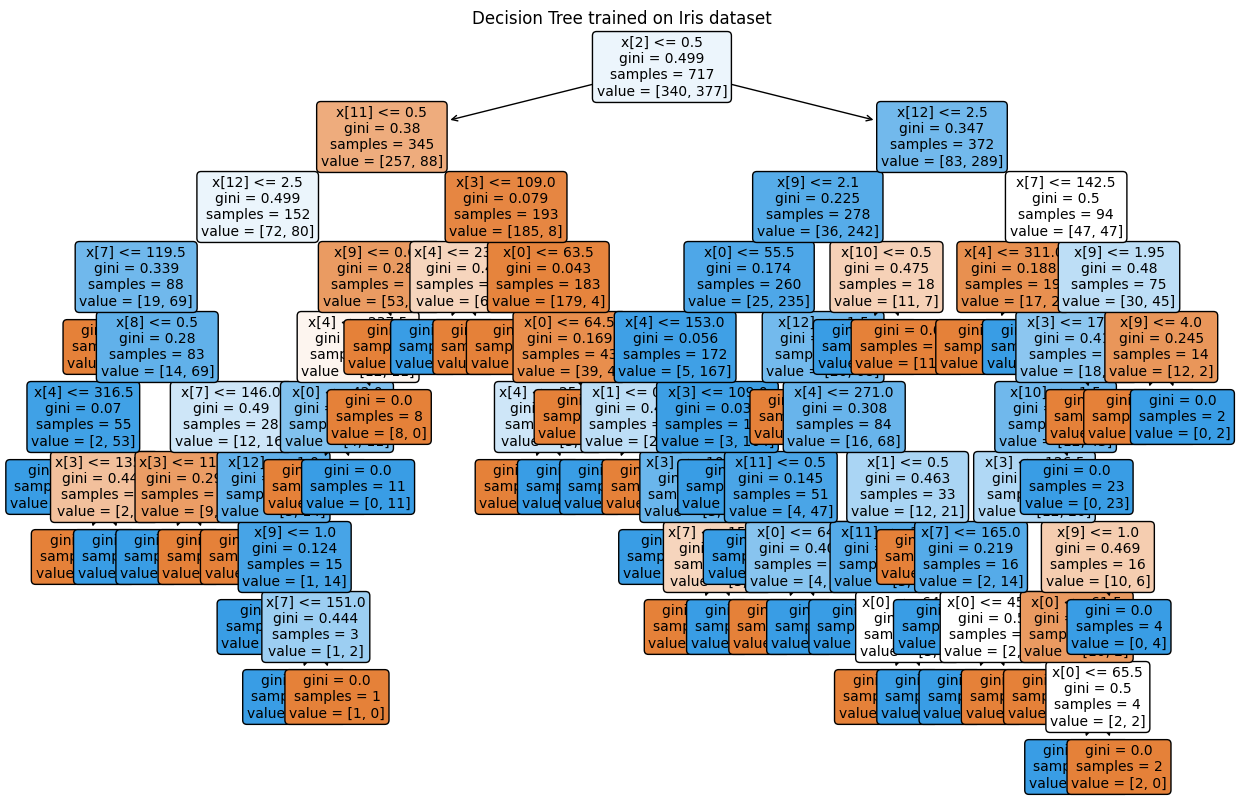

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
plot_tree(dt_classifier,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree trained on Iris dataset")
plt.show()

In [23]:
from sklearn.metrics import accuracy_score

y_pred_dt = dt_classifier.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(accuracy_dt)

0.9707792207792207


##  2.Analyze overfitting and control tree depth.


In [24]:
dt_constrained = DecisionTreeClassifier(max_depth=3, random_state=42) # Constrained depth
dt_constrained.fit(X_train, y_train)

train_accuracy_constrained = accuracy_score(y_train, dt_constrained.predict(X_train))
test_accuracy_constrained = accuracy_score(y_test, dt_constrained.predict(X_test))

In [25]:
print(f"\nConstrained Decision Tree (max_depth=3):")
print(f"  Training Accuracy: {train_accuracy_constrained:.4f}")
print(f"  Testing Accuracy: {test_accuracy_constrained:.4f}")


## accuracy shows, how it becomes overfitting 


Constrained Decision Tree (max_depth=3):
  Training Accuracy: 0.8577
  Testing Accuracy: 0.8052


##  3.Train a Random Forest and compare accuracy.


In [26]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42) # 100 trees in the forest
rf_classifier.fit(X_train, y_train)

y_pred_rf = rf_classifier.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)


In [27]:
y_pred_rf = rf_classifier.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(accuracy_rf)

0.9805194805194806


##  4.Interpret feature importances.


In [28]:
feature_importances = rf_classifier.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]

In [29]:
feature_names = X.columns.tolist()

for idx in sorted_idx:
    print(f"  {feature_names[idx]}: {feature_importances[idx]:.4f}")

  cp: 0.1323
  thalach: 0.1250
  ca: 0.1229
  oldpeak: 0.1229
  thal: 0.1130
  age: 0.0856
  chol: 0.0799
  trestbps: 0.0684
  slope: 0.0513
  exang: 0.0422
  sex: 0.0287
  restecg: 0.0182
  fbs: 0.0097


##  5.Evaluate using cross-validation.


In [32]:
from sklearn.model_selection import  cross_val_score
cv_scores_dt = cross_val_score(dt_classifier, X, y, cv=5)

cv_scores_rf = cross_val_score(rf_classifier, X, y, cv=5)

In [35]:
print("cv_scores_dt- " ,cv_scores_dt, "cv_scores_rf:",cv_scores_dt)

cv_scores_dt-  [1. 1. 1. 1. 1.] cv_scores_rf: [1. 1. 1. 1. 1.]


somhow accuracy is 100% in both 